<a href="https://colab.research.google.com/github/NeLy-EPFL/flygym/blob/v2.1.0/tutorials/4c_hybrid_controller.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> ⚠️ **Running on Google Colab?** Execution there can be **up to ~50× slower** than on a local machine or dedicated GPU, depending on the resources Colab makes available at the time. Use Colab only for testing and following along with the tutorials—not for production runs or benchmarking.

In [1]:
# --- Google Colab setup ---
# If you opened this notebook in Google Colab, run this cell first to
# install FlyGym and enable headless (EGL) rendering. It is a no-op when
# the notebook is run anywhere else.
import os
import sys

if "google.colab" in sys.modules:
    os.environ["MUJOCO_GL"] = "egl"
    os.environ["PYOPENGL_PLATFORM"] = "egl"
    %pip install -q tqdm "flygym @ git+https://github.com/NeLy-EPFL/flygym.git@v2.1.0"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 117.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have nu

# Hybrid locomotion controller

This tutorial runs the v2 hybrid walking controller on mixed terrain. The controller combines tripod CPG stepping with local retraction and stumbling corrections, then renders the rollout directly in the notebook.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from tqdm import trange

from flygym import Simulation
from flygym.anatomy import BodySegment, ContactBodiesPreset
from flygym.compose import MixedTerrainWorld
from flygym_demo.complex_terrain import (
    HybridController,
    HybridControllerObservation,
    LocomotionAction,
    PreprogrammedSteps,
    apply_locomotion_action,
    make_locomotion_fly,
)
from flygym.utils.math import Rotation3D


output_dir = Path("demo_output/hybrid_controller")
output_dir.mkdir(parents=True, exist_ok=True)

In [3]:
fly = make_locomotion_fly(
    name="hybrid_demo",
    add_adhesion=True,
    colorize=True,
)
body_cam = fly.add_tracking_camera(
    name="body_cam",
    pos_offset=(-0.5, -7.5, 0.0),
    rotation=Rotation3D("euler", (1.57, 0.0, 0.0)),
    fovy=35.0,
)

world = MixedTerrainWorld()
world.add_fly(
    fly,
    [0, 0, 1.2],
    Rotation3D("quat", [1, 0, 0, 0]),
    bodysegs_with_ground_contact=ContactBodiesPreset.TIBIA_TARSUS_ONLY,
    add_ground_contact_sensors=False,
)

sim = Simulation(world)
renderer = sim.set_renderer(
    [body_cam],
    camera_res=(240, 320),
    playback_speed=0.1,
    output_fps=25,
)

In [4]:
preprogrammed_steps = PreprogrammedSteps()
dof_order = fly.get_actuated_jointdofs_order("position")
controller = HybridController(
    timestep=sim.timestep,
    preprogrammed_steps=preprogrammed_steps,
    output_dof_order=dof_order,
)

print("Actuated DoFs:", len(dof_order))
print("Simulation timestep:", sim.timestep)
print(
    "Controller CPG frequency (Hz):", float(controller.cpg_network.intrinsic_freqs[0])
)

Actuated DoFs: 42
Simulation timestep: 0.0001
Controller CPG frequency (Hz): 12.0


In [5]:
sim.reset()
controller.reset(seed=0)

initial_action = LocomotionAction(
    joint_angles=preprogrammed_steps.default_pose_by_dof_order(dof_order),
    adhesion_onoff=np.ones(6, dtype=bool),
)
apply_locomotion_action(sim, fly.name, initial_action)
sim.warmup()

In [6]:
run_time = 2.0
nsteps_sim = int(run_time / sim.timestep)
time_grid = np.arange(nsteps_sim) * sim.timestep

thorax_idx = fly.get_bodysegs_order().index(BodySegment("c_thorax"))
thorax_positions = np.full((nsteps_sim, 3), np.nan, dtype=np.float32)
adhesion_onoff = np.zeros((nsteps_sim, 6), dtype=bool)
net_corrections = np.full((nsteps_sim, 6), np.nan, dtype=np.float32)

for step_idx in trange(nsteps_sim, desc="Running hybrid controller"):
    obs = HybridControllerObservation.from_sim(sim, fly.name)
    action = controller.step(obs)
    apply_locomotion_action(sim, fly.name, action)
    sim.step_with_profile()

    thorax_positions[step_idx] = sim.get_body_positions(fly.name)[thorax_idx]
    adhesion_onoff[step_idx] = action.adhesion_onoff
    net_corrections[step_idx] = controller.last_info["net_corrections"]

    sim.render_as_needed_with_profile()

print("Rendered frames:", len(renderer.frames[body_cam.name]))
print(
    "Thorax forward displacement:",
    f"{thorax_positions[-1, 0] - thorax_positions[0, 0]:.2f} mm",
)
sim.print_performance_report()

Running hybrid controller: 100%|██████████| 20000/20000 [01:50<00:00, 181.31it/s]

Rendered frames: 500
Thorax forward displacement: 15.33 mm

                                   PERFORMANCE PROFILE                                    
┌────────────────────────────────┬─────────────┬───────────┬──────────────┬──────────────┐
│                                │   Time/step │   Percent │   Throughput │   Throughput │
│ Stage                          │        (us) │       (%) │    (iters/s) │   x realtime │
├────────────────────────────────┼─────────────┼───────────┼──────────────┼──────────────┤
│ Physics simulation advancement │         927 │        25 │         1078 │         0.11 │
├────────────────────────────────┼─────────────┼───────────┼──────────────┼──────────────┤
│ Rendering*                     │        2793 │        75 │          358 │         0.04 │
├────────────────────────────────┼─────────────┼───────────┼──────────────┼──────────────┤
│ TOTAL                          │        3721 │       100 │          269 │         0.03 │
└─────────────────────────────

In [7]:
sim.renderer.show_in_notebook()
sim.renderer.save_video(output_dir / "hybrid_controller_mixed_terrain.mp4")

hybrid_demo/body_cam This browser does not support the video tag.


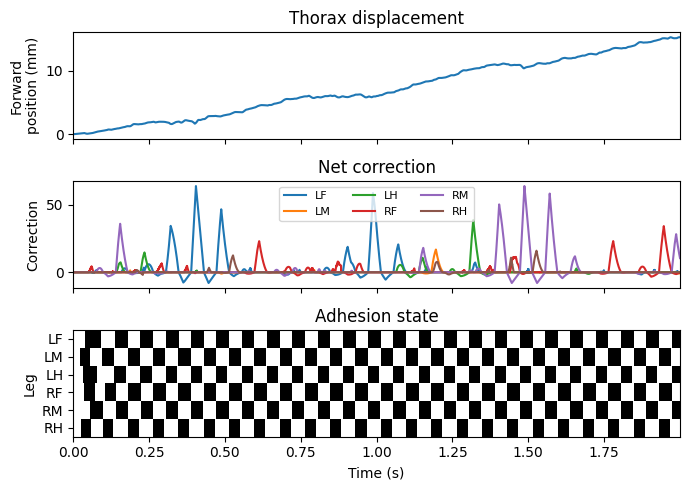

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(7, 5), tight_layout=True, sharex=True)

axes[0].plot(time_grid, thorax_positions[:, 0] - thorax_positions[0, 0])
axes[0].set_ylabel("Forward\nposition (mm)")
axes[0].set_title("Thorax displacement")

for leg_idx, leg in enumerate(preprogrammed_steps.legs):
    axes[1].plot(time_grid, net_corrections[:, leg_idx], label=leg.upper())
axes[1].set_ylabel("Correction")
axes[1].set_title("Net correction")
axes[1].legend(ncols=3, fontsize=8)

axes[2].imshow(
    adhesion_onoff.T,
    aspect="auto",
    interpolation="nearest",
    extent=(time_grid[0], time_grid[-1], 5.5, -0.5),
    cmap="gray",
)
axes[2].set_yticks(np.arange(6))
axes[2].set_yticklabels([leg.upper() for leg in preprogrammed_steps.legs])
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Leg")
axes[2].set_title("Adhesion state")

fig.savefig(output_dir / "hybrid_controller_diagnostics.png")